### Autoenkodery ###

In [42]:
import numpy as np
from keras.datasets import mnist
import keras
from keras import layers
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from matplotlib import pyplot as plt

In [43]:
#Wczytanie i konwersja danych
training_set, test_set = mnist.load_data()

X_train, y_train = training_set
X_test, y_test = test_set

X_train = np.expand_dims(X_train, -1)
X_test = np.expand_dims(X_test, -1)
print(X_train.shape)

X_train = X_train.astype(np.float64) / 255.0  
X_test = X_test.astype(np.float64) / 255.0

(60000, 28, 28, 1)


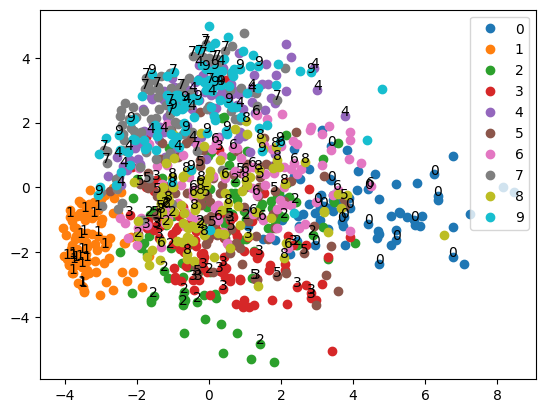

In [44]:
#Redukcja wymiarowości z wykorzystaniem PCA
X_train_flatten = np.reshape(X_train, (X_train.shape[0], X_train.shape[1]*X_train.shape[2]))
X_test_flatten = np.reshape(X_test, (X_test.shape[0], X_test.shape[1]*X_test.shape[2]))

pca = PCA()
pca.fit(X_train_flatten)

Z_test_flatten = pca.transform(X_test_flatten)
Z_test_subset, _, y_test_subset, _ = train_test_split(Z_test_flatten, y_test, train_size=0.1, random_state=41203)

plt.figure()
for i in range(10):
    X_tmp = Z_test_subset[y_test_subset == i]
    plt.plot(X_tmp[:,0], X_tmp[:,1], 'o')
    for j in range(0, len(X_tmp), 5):
        plt.annotate(i, (X_tmp[j,0], X_tmp[j,1]), ha='center')
plt.legend(range(10))
plt.show()

In [45]:
X_train_flatten.shape

(60000, 784)

In [46]:
#Redukcja wymiarowości z wykorzystaniem autoenkodera

#przygotowanie modelu
input_shape = (28,28,1)

inputs = layers.Input(shape=input_shape)

flatten = layers.Flatten()(inputs)
dense1 = layers.Dense(50, activation='tanh')(flatten) #funkcje 'tanh' wprowadzaja nieliniowosc
dense2 = layers.Dense(50, activation='tanh')(dense1)
latent = layers.Dense(2, activation='linear')(dense2) #stopniowa redukcja az do warstwy srodkowej
dense3 = layers.Dense(50, activation='tanh')(latent) #kolejne warstwy to proba rekonstrukcji wejscia z formy skompresowanej
dense4 = layers.Dense(50, activation='tanh')(dense3)
dense5 = layers.Dense(28*28, activation='relu')(dense4)
outputs = layers.Reshape(target_shape=(28,28,1))(dense5)

model = keras.Model(inputs=inputs, outputs=outputs)

model.compile(loss='mse', optimizer='adam', metrics=['mse'])

In [47]:
batch_size = 128
epochs = 50
model.fit(X_train, X_train, batch_size=batch_size, epochs=epochs, validation_split=0.2)

Epoch 1/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - loss: 0.0718 - mse: 0.0718 - val_loss: 0.0562 - val_mse: 0.0562
Epoch 2/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0544 - mse: 0.0544 - val_loss: 0.0486 - val_mse: 0.0486
Epoch 3/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0486 - mse: 0.0486 - val_loss: 0.0463 - val_mse: 0.0463
Epoch 4/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 0.0467 - mse: 0.0467 - val_loss: 0.0451 - val_mse: 0.0451
Epoch 5/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 0.0453 - mse: 0.0453 - val_loss: 0.0442 - val_mse: 0.0442
Epoch 6/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0444 - mse: 0.0444 - val_loss: 0.0436 - val_mse: 0.0436
Epoch 7/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0437 - mse: 0.0437 - val_loss: 0.0431 - val_mse: 0.0431
Epoch 8/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0433 - mse: 0.0433 - val_loss: 0.0427 - val_mse: 0.0427
Epoch 9/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - l

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


<Figure size 640x480 with 0 Axes>

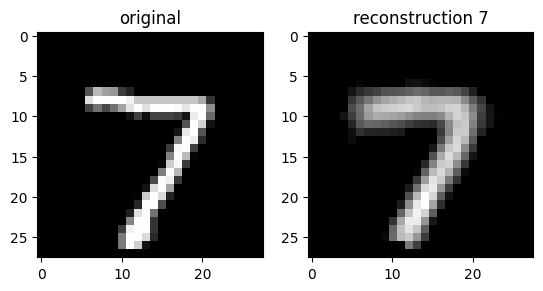

In [48]:
#predykcja
X_gen = model.predict(X_test)

example_id = 0

plt.figure()
fig, axs = plt.subplots(1,2)
axs[0].imshow(X_test[example_id,:,:, 0], cmap='gray')
axs[0].set_title('original')
axs[1].imshow(X_gen[example_id,:,:, 0], cmap='gray')
axs[1].set_title(f'reconstruction {y_test[example_id]}')
plt.show()

#wynik rekonstrukcji zostal odtworzony z 2 wartości warstwy latent

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


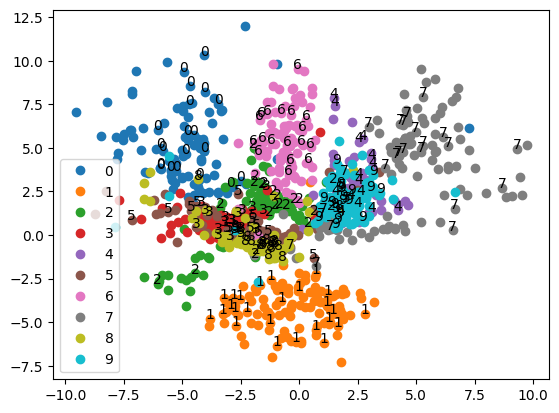

In [51]:
#Aby zwizualizować gdzie znajdują się poszczególne przykłady w ich reprezentacji ukrytej,
#możemy “przeciąć” nasza sieć w pół i wygenerować odpowiedzi warstwy latent

compression_model = keras.Model(inputs=inputs, outputs=latent)

X_test_subset, _, y_test_subset, _ = train_test_split(X_test, y_test, train_size=0.1, random_state=42103)
X_compressed = compression_model.predict(X_test_subset)

plt.figure()
for i in range(10):
    X_tmp = X_compressed[y_test_subset == i]
    plt.plot(X_tmp[:,0], X_tmp[:,1], 'o')
    for j in range(1, len(X_tmp), 5):
        plt.annotate(i, (X_tmp[j,0], X_tmp[j,1]), ha='center')
plt.legend(range(10))
plt.show()

#Widac, ze autoenkoder lepiej poradzil sobie z kompresja danych wejsciowych do 2 wartosci

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step


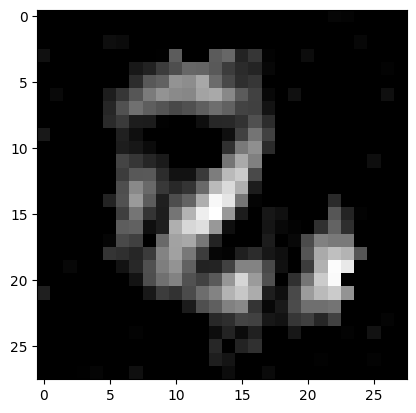

In [55]:
#można wydzielić drugą część sieci (dekoder) i wygenerować kilka przykładów

decoder = keras.Model(inputs=latent, outputs=outputs)
input_data = np.array([[-12.0, -2.0]])
random_img = decoder.predict(input_data)
plt.imshow(random_img[0,:,:,0], cmap='gray')
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━

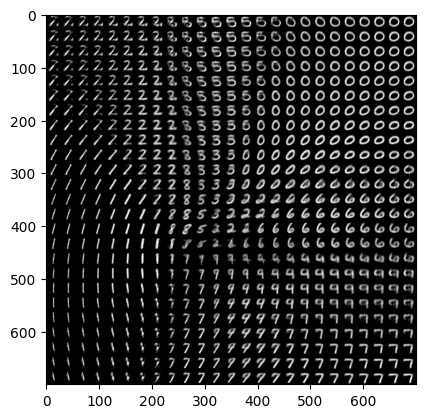

In [56]:
#Bądź zbadać całą przestrzeń z odpowiednim próbkowaniem

xs = np.linspace(-10, 6, 25)
ys = np.linspace(-7, 10, 25)
all_img = np.zeros([len(xs)*28, len(ys)*28], dtype=np.float32)
for i, x in enumerate(xs):
    for j, y in enumerate(ys):
        input_data = np.array([[x,y]])
        random_img = decoder.predict(input_data)
        all_img[i*28:(i+1)*28, j*28:(j+1)*28] = random_img[0,:,:,0]
all_img[all_img > 1.0] = 1.0
plt.imshow(all_img[:,:], cmap='gray')
plt.show()